In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA Notebook Ready")

EDA Notebook Ready


In [53]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)


In [54]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [55]:
nav['date'] = pd.to_datetime(nav['date'])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639

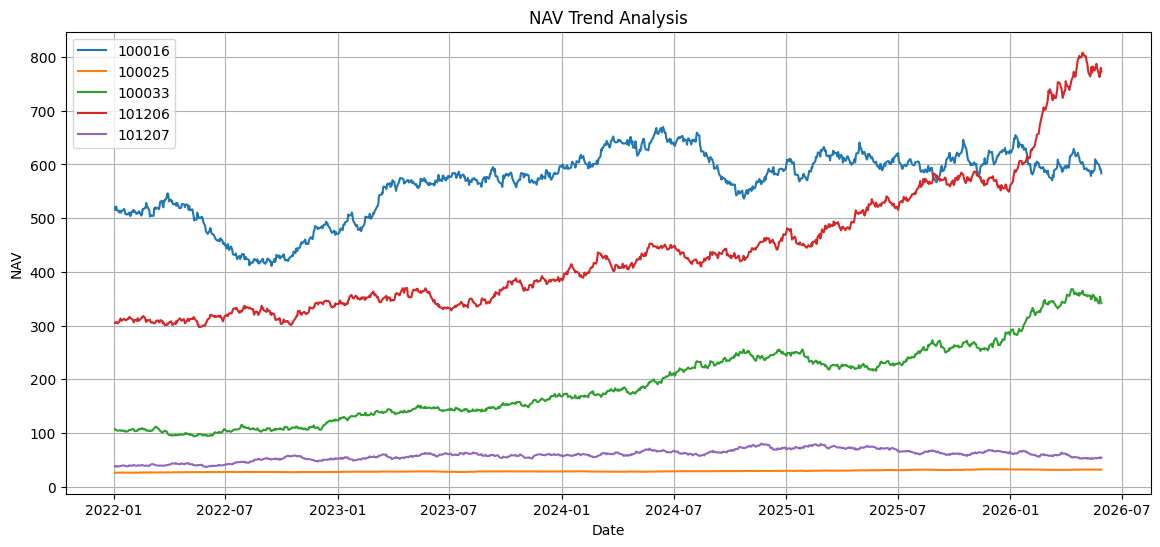

In [56]:
plt.figure(figsize=(14,6))

for fund in nav['amfi_code'].unique()[:5]:
    temp = nav[nav['amfi_code'] == fund]
    plt.plot(temp['date'], temp['nav'], label=str(fund))

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.savefig("../reports/nav_trend.png", bbox_inches="tight")

plt.show()

In [57]:
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


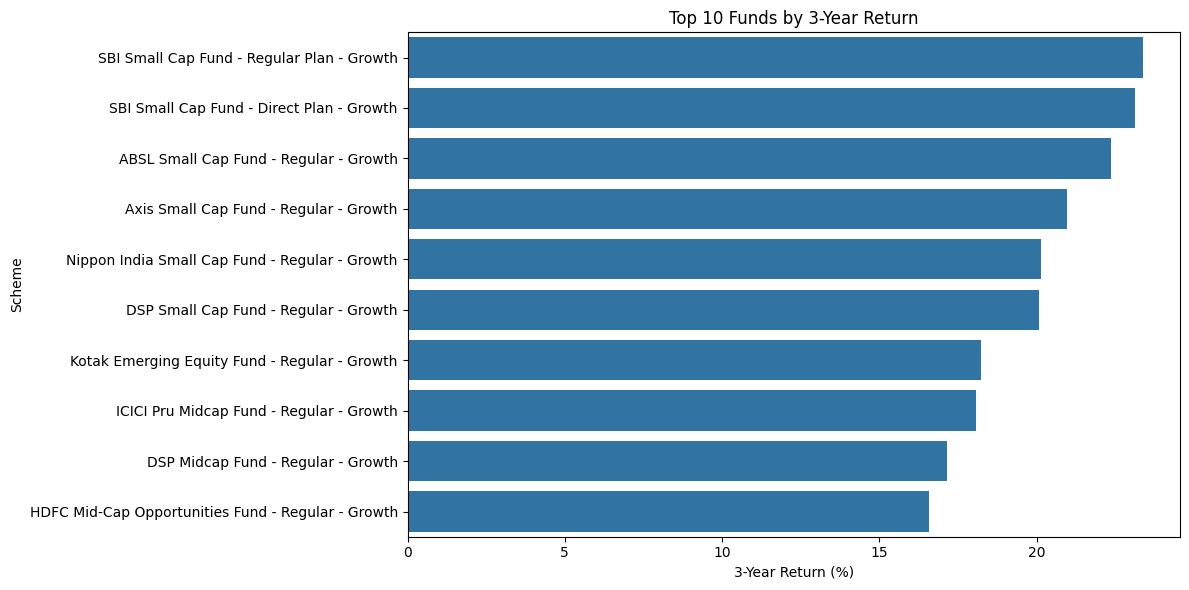

In [58]:
top10 = performance.sort_values(
    by='return_3yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='return_3yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.savefig("../reports/top_10_returns.png", bbox_inches="tight")
plt.show()

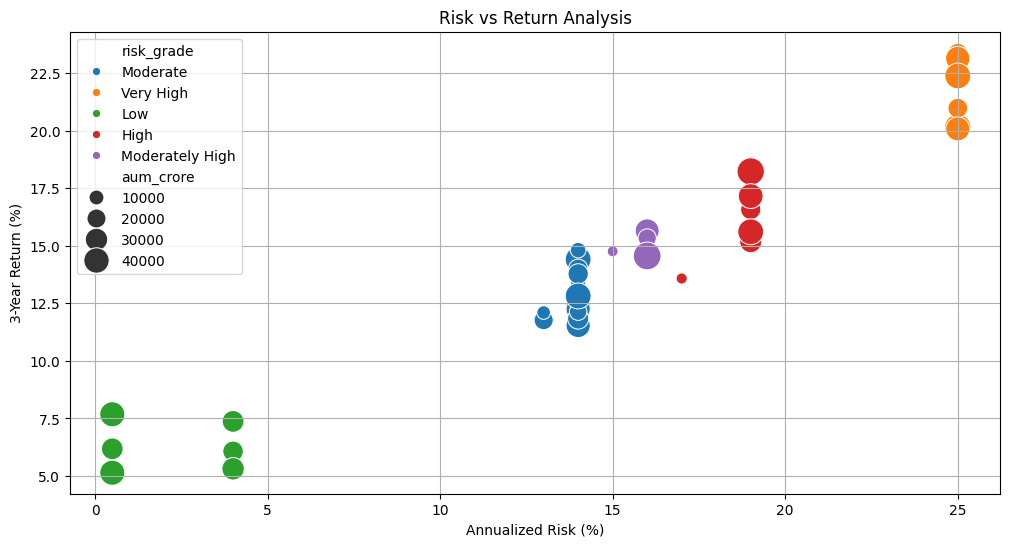

In [59]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    hue='risk_grade',
    size='aum_crore',
    sizes=(50, 400)
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Annualized Risk (%)")
plt.ylabel("3-Year Return (%)")

plt.grid(True)
plt.savefig("../reports/risk_vs_return.png", bbox_inches="tight")
plt.show()

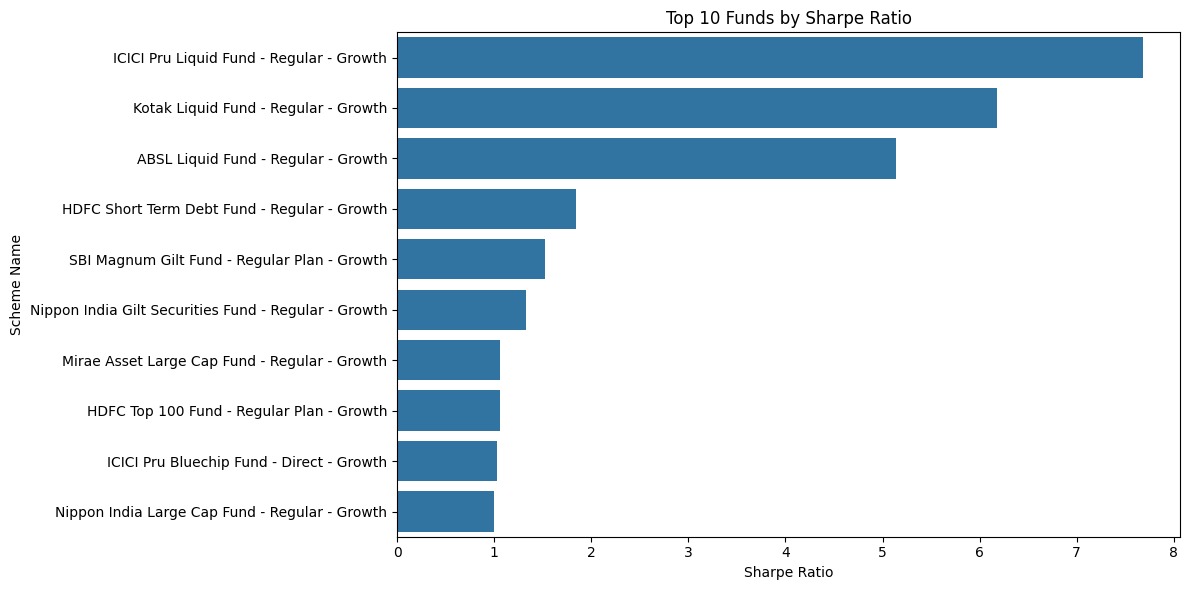

In [60]:
top_sharpe = performance.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.savefig("../reports/top_10_sharpe_ratio.png", bbox_inches="tight")
plt.show()

In [61]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


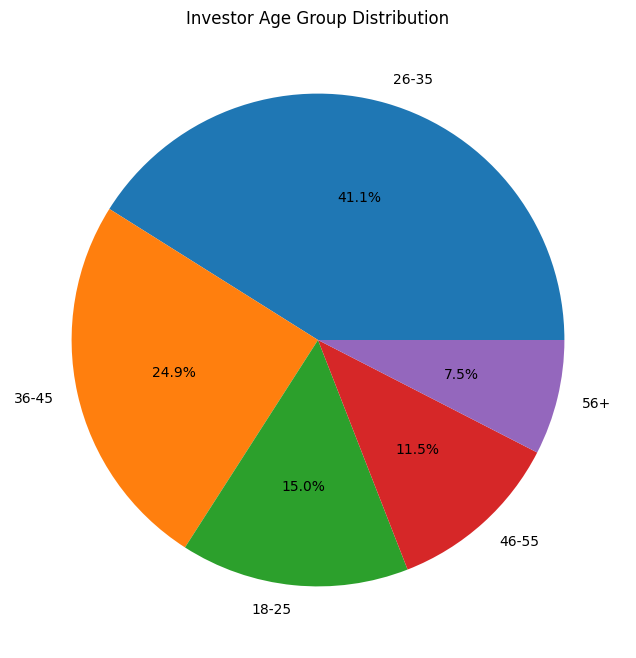

In [62]:
plt.figure(figsize=(8,8))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.savefig("../reports/age_group_distribution.png", bbox_inches="tight")
plt.show()

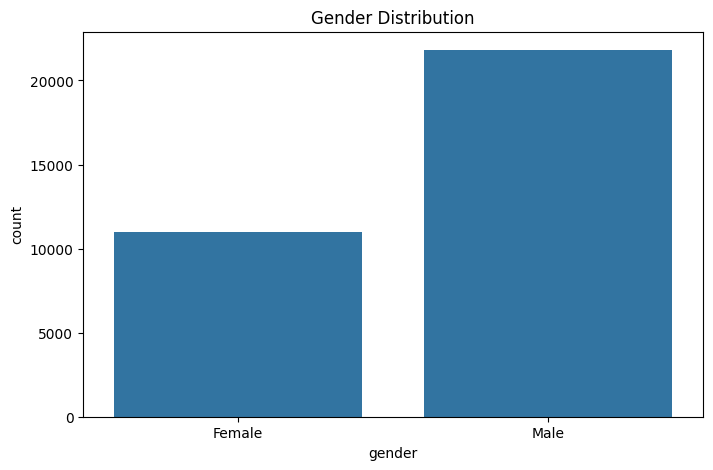

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title("Gender Distribution")
plt.savefig("../reports/gender_distribution.png", bbox_inches="tight")
plt.show()

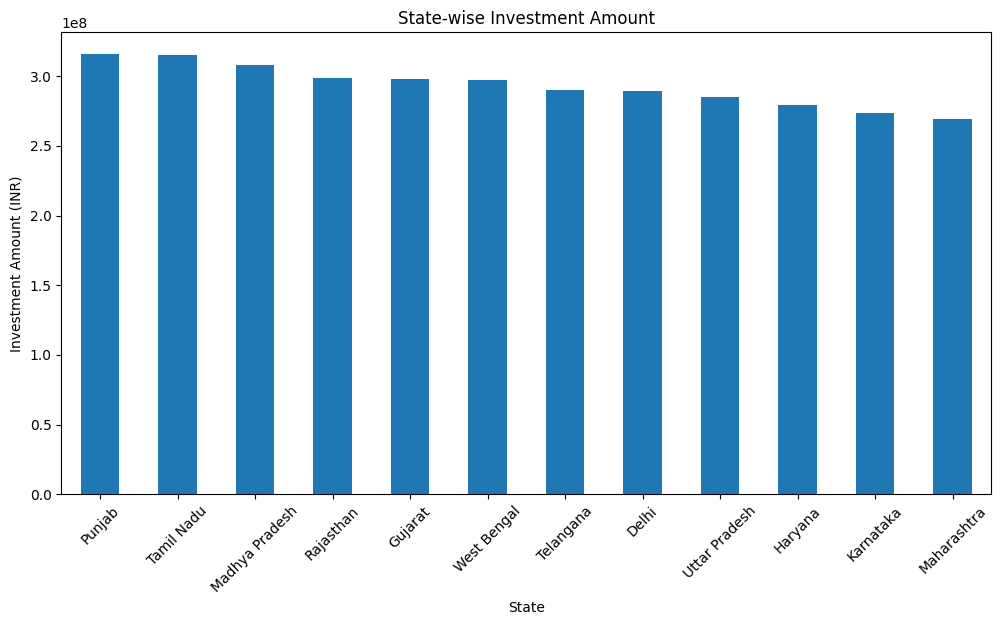

In [64]:
state_investment = (
    transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_investment.plot(kind='bar')

plt.title("State-wise Investment Amount")
plt.ylabel("Investment Amount (INR)")
plt.xlabel("State")

plt.xticks(rotation=45)
plt.savefig("../reports/state_wise_investment.png", bbox_inches="tight")
plt.show()

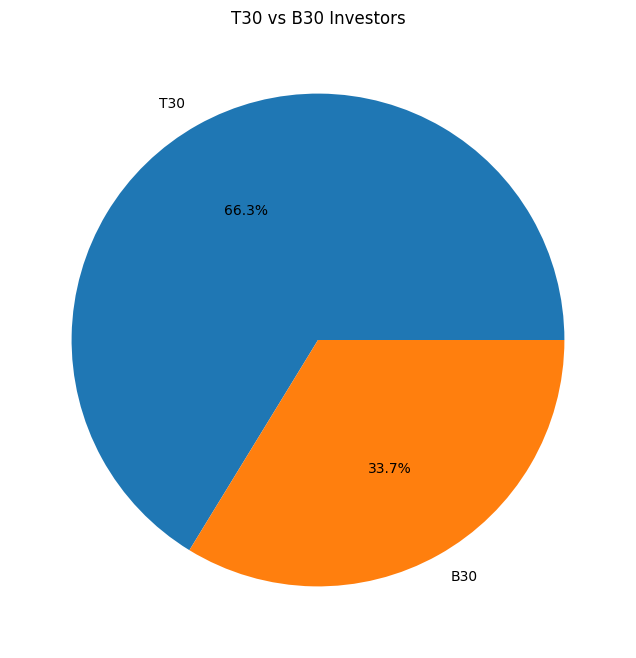

In [65]:
plt.figure(figsize=(8,8))

transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investors")
plt.ylabel("")
plt.savefig("../reports/t30_vs_b30.png", bbox_inches="tight")
plt.show()

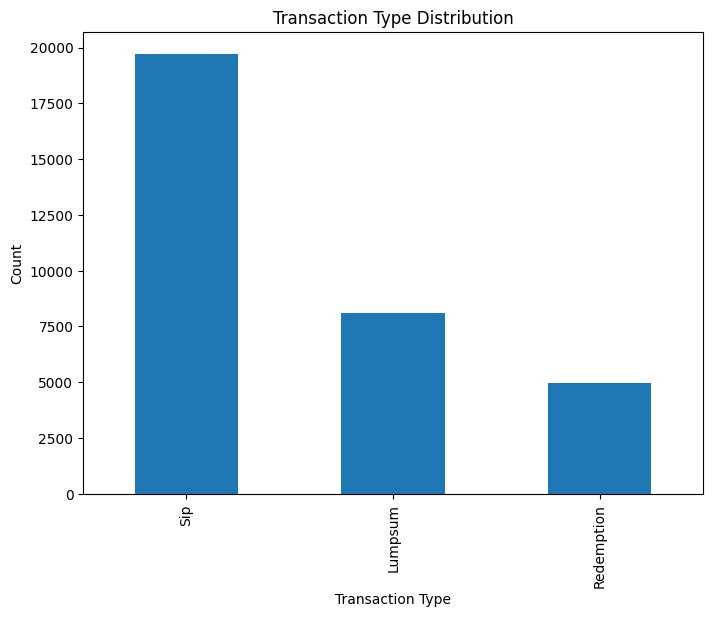

In [66]:
plt.figure(figsize=(8,6))

transactions['transaction_type'].value_counts().plot(
    kind='bar'
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.savefig("../reports/transaction_type_distribution.png", bbox_inches="tight")
plt.show()

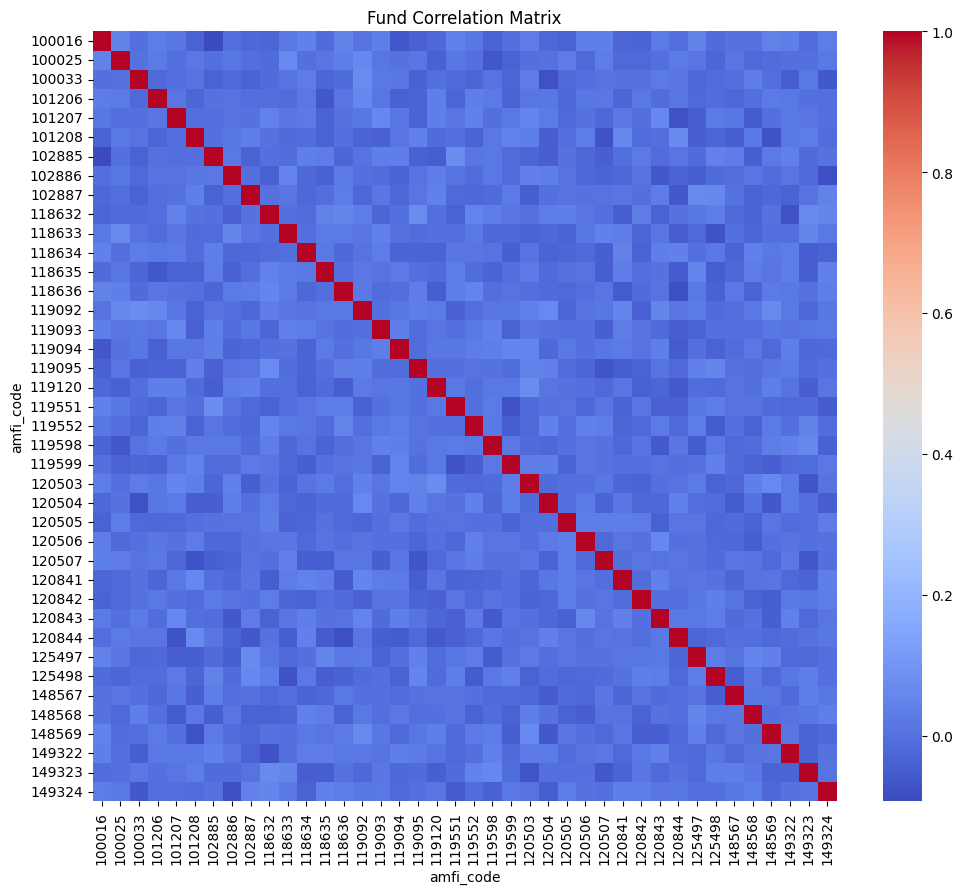

In [67]:
pivot_nav = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Fund Correlation Matrix")
plt.savefig("../reports/correlation_matrix.png", bbox_inches="tight")
plt.show()

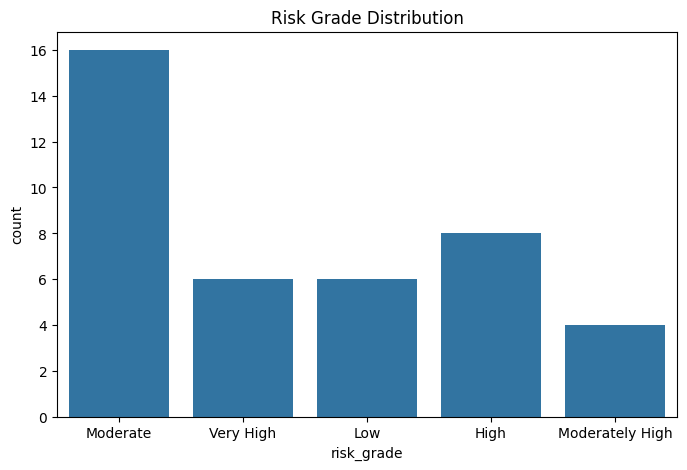

In [68]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x='risk_grade'
)

plt.title("Risk Grade Distribution")
plt.savefig("../reports/risk_grade_distribution.png", bbox_inches="tight")
plt.show()

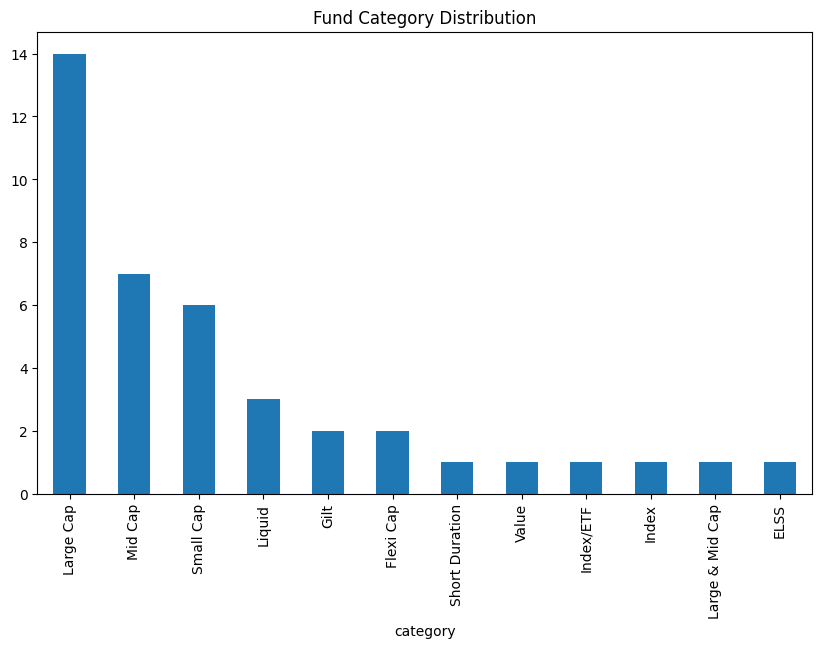

In [69]:
plt.figure(figsize=(10,6))

performance['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fund Category Distribution")
plt.savefig("../reports/fund_category_distribution.png", bbox_inches="tight")
plt.show()

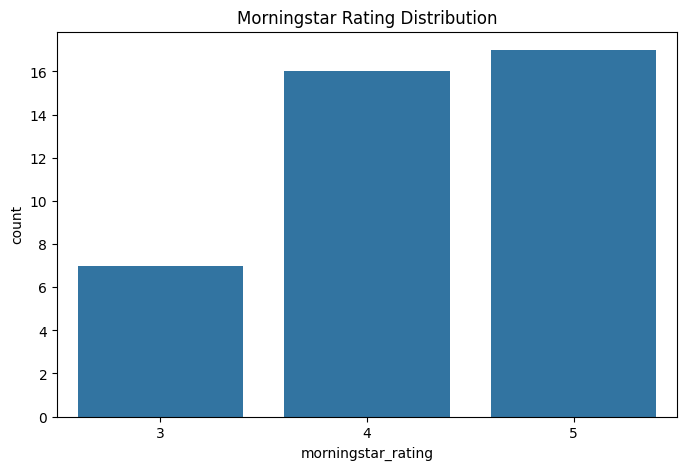

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x='morningstar_rating'
)

plt.title("Morningstar Rating Distribution")
plt.savefig("../reports/morningstar_rating_distribution.png", bbox_inches="tight")
plt.show()

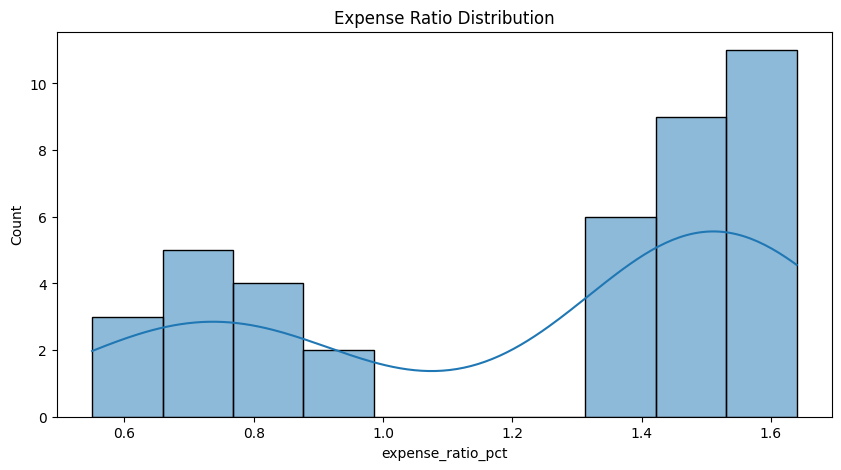

In [71]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance['expense_ratio_pct'],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.savefig("../reports/expense_ratio_distribution.png", bbox_inches="tight")
plt.show()

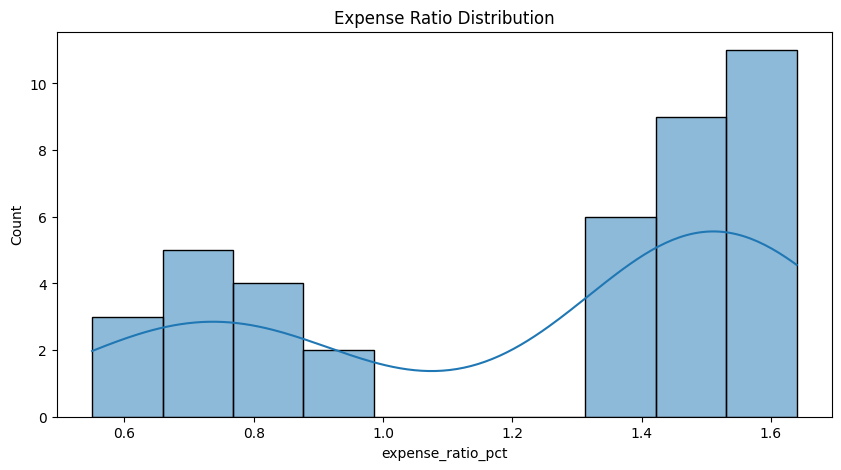

In [72]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance['expense_ratio_pct'],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.savefig("../reports/expense_ratio_distribution.png", bbox_inches="tight")
plt.show()

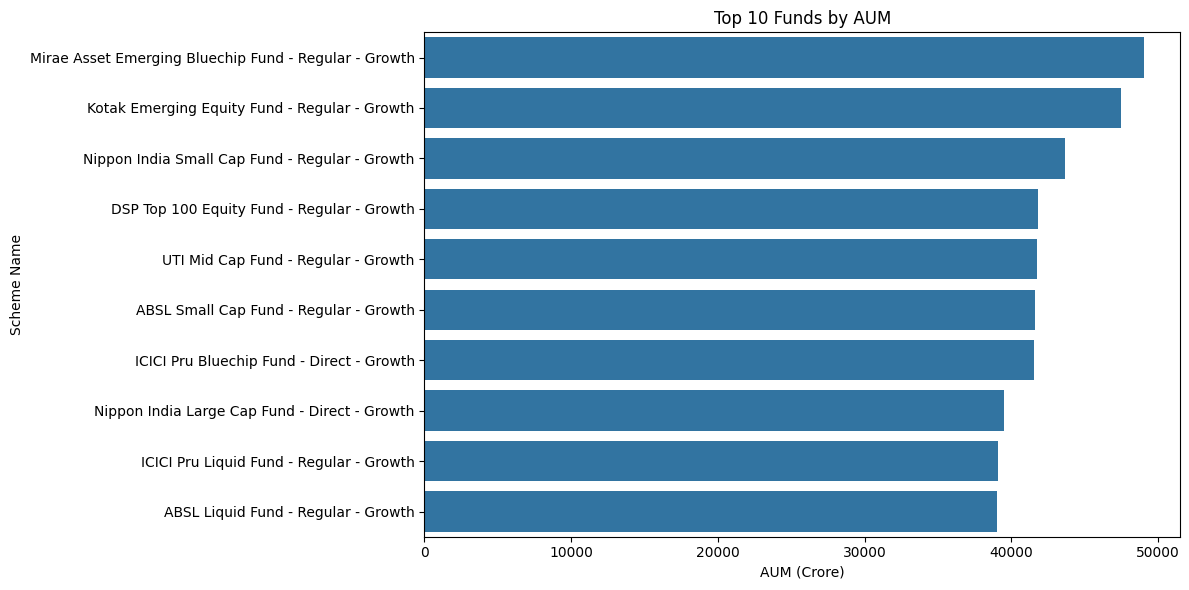

In [73]:
top_aum = performance.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x='aum_crore',
    y='scheme_name'
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig("../reports/top_10_funds_by_aum.png", bbox_inches="tight")

plt.show()

# Day 3 - EDA Findings

## Key Findings

1. SBI Small Cap Fund delivered the highest 3-year return among analyzed funds.
2. Small-cap funds dominated the top-performing fund rankings.
3. Higher-risk funds generally generated higher returns.
4. Liquid funds showed strong Sharpe Ratios indicating good risk-adjusted performance.
5. Maharashtra contributed the highest investment volume.
6. T30 cities accounted for the majority of investor participation.
7. SIP transactions formed the largest share of transactions.
8. Most funds showed positive correlation with one another.
9. Moderate and High Risk categories were the most common fund types.
10. Expense ratios were concentrated within a relatively narrow range.

In [74]:
import matplotlib.pyplot as plt
import os

os.makedirs("../reports", exist_ok=True)

for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(f"../reports/chart_{i}.png", bbox_inches="tight")

print("All open charts saved successfully!")

All open charts saved successfully!
